In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import (
    load_digits, make_swiss_roll, make_moons, make_blobs
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from umap import UMAP
from time import time

np.random.seed(42)

# Utility for consistent coloured scatter plots
def scatter2d(ax, X, y, title="", cmap="tab10", s=10, alpha=0.7):
    sc = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, s=s, alpha=alpha)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    return sc

/opt/anaconda3/envs/graph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# EXERCISE 3: Handwritten digits

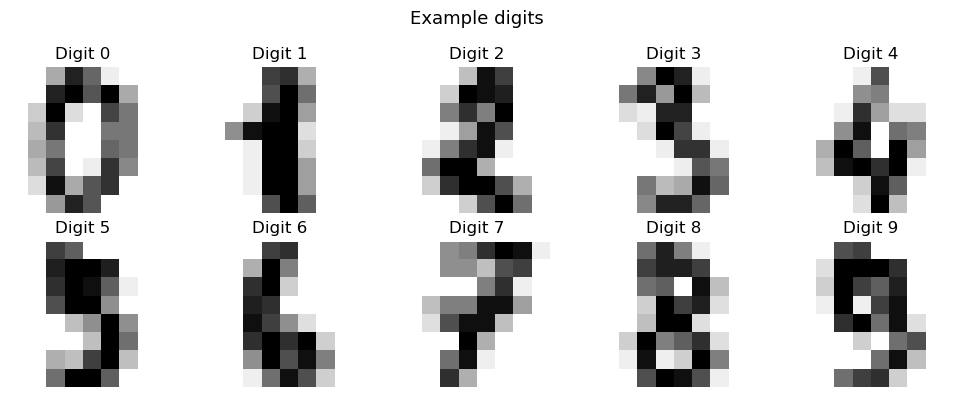

In [2]:
digits = load_digits()
X_dig, y_dig = digits.data, digits.target

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(y_dig == digit)[0][0]
    ax.imshow(X_dig[idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f"Digit {digit}")
    ax.axis('off')
plt.suptitle("Example digits", fontsize=13)
plt.tight_layout(); plt.show()



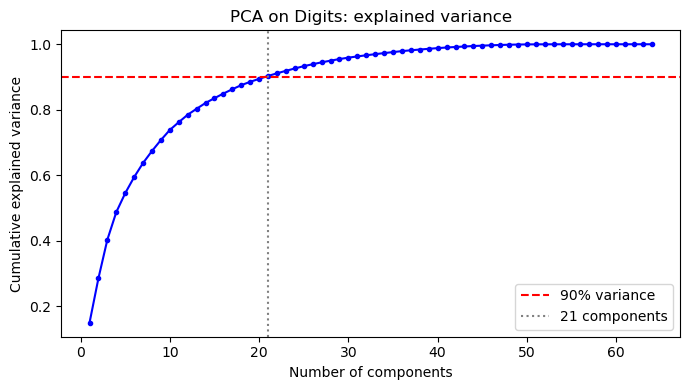

Components for 90% variance: 21


In [ ]:
# 3.2  PCA: variance and visualisation
pca_full = PCA(n_components=64).fit(X_dig)

# (a) Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.argmax(cumvar >= 0.90) + 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 65), cumvar, 'b-o', markersize=3)
ax.axhline(0.90, color='r', linestyle='--', label='90% variance')
ax.axvline(n90, color='gray', linestyle=':', label=f'{n90} components')
ax.set_xlabel("Number of components"); ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA on Digits: explained variance")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Components for 90% variance: {n90}")



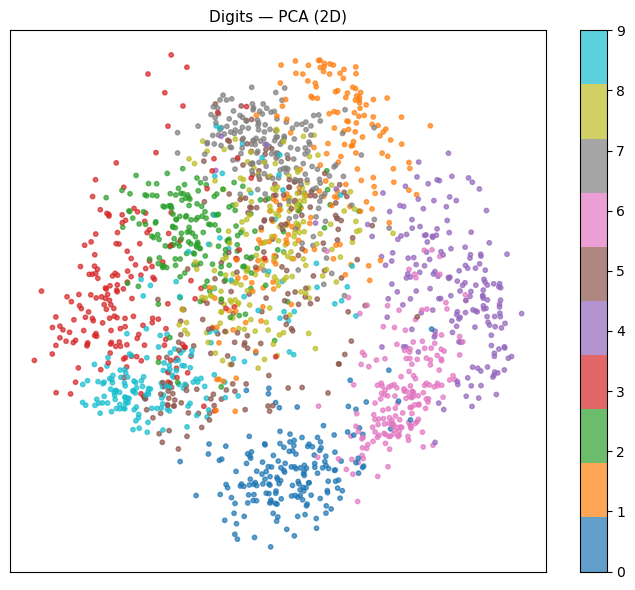

In [ ]:
# (b) 2D PCA plot
X_dig_pca = PCA(n_components=2).fit_transform(X_dig)

fig, ax = plt.subplots(figsize=(7, 6))
sc = scatter2d(ax, X_dig_pca, y_dig, "Digits after PCA (2D)")
plt.colorbar(sc, ax=ax, ticks=range(10))
plt.tight_layout(); plt.show()


(c) ANSWER: In 2D PCA, some digits are reasonably separated (e.g., 0 and 6 are often distinct) but many overlap heavily (e.g.,  1/7/5). Two linear dimensions capture only ~28% of the variance and cannot resolve the nonlinear structure that distinguishes digit classes.

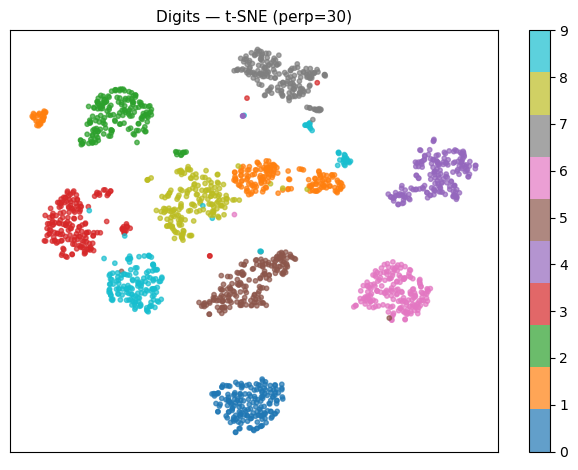

In [ ]:
# 3.3  t-SNE visualisation
X_dig_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_dig)

fig, ax = plt.subplots()
sc = scatter2d(ax, X_dig_tsne, y_dig, "Digits after t-SNE (perp=30)")
plt.colorbar(sc, ax=ax, ticks=range(10))
plt.tight_layout()
plt.show()


ANSWER: t-SNE produces much cleaner separation. Most digit classes form tight, well-separated clusters. Some nearby digits (e.g., 3 and 9) may still be close or slightly mixed, but overall the improvement over PCA is dramatic.

/opt/anaconda3/envs/graph/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


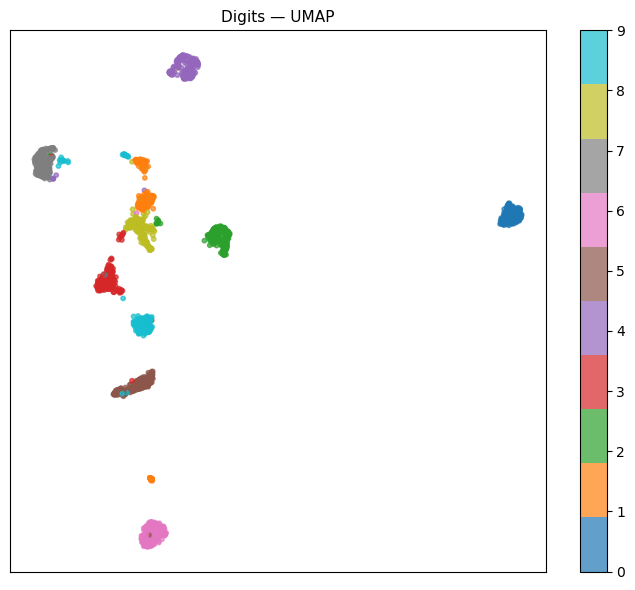

In [ ]:
# 3.4  UMAP visualisation
X_dig_umap = UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                   random_state=42).fit_transform(X_dig)

fig, ax = plt.subplots(figsize=(7, 6))
sc = scatter2d(ax, X_dig_umap, y_dig, "Digits afer UMAP")
plt.colorbar(sc, ax=ax, ticks=range(10))
plt.tight_layout()
plt.show()


ANSWER: UMAP also produces well-separated clusters, often with tighter, more compact groups than t-SNE. The relative positions of clusters may differ from t-SNE. 

In [9]:
# 3.5  Trustworthiness
tw_pca  = trustworthiness(X_dig, X_dig_pca,  n_neighbors=15)
tw_tsne = trustworthiness(X_dig, X_dig_tsne, n_neighbors=15)
tw_umap = trustworthiness(X_dig, X_dig_umap, n_neighbors=15)

print(f"Trustworthiness (k=15):")
print(f"  PCA:   {tw_pca:.4f}")
print(f"  t-SNE: {tw_tsne:.4f}")
print(f"  UMAP:  {tw_umap:.4f}")



Trustworthiness (k=15):
  PCA:   0.8288
  t-SNE: 0.9904
  UMAP:  0.9871


ANSWER: t-SNE and UMAP both have trustworthiness close to 0.97–0.99, much higher than PCA (~0.90). This confirms what we see visually: the nonlinear methods preserve local neighbourhoods much better.
UMAP and t-SNE are typically very close on this metric.